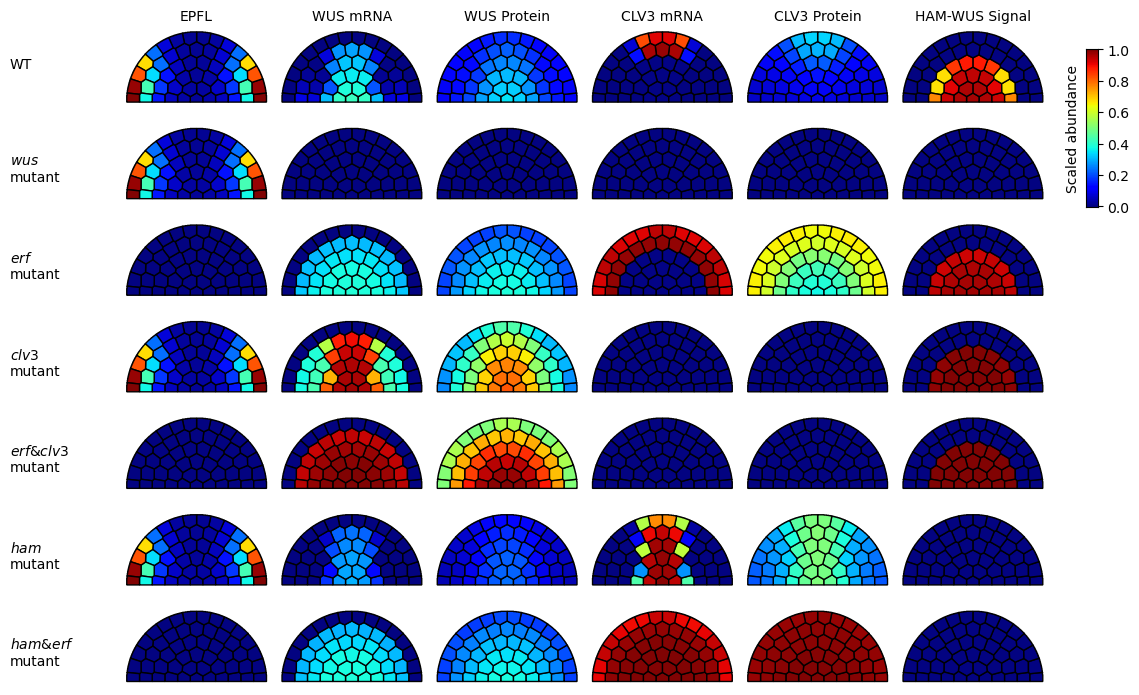

In [1]:
import re
import numpy as np
import Model2d_shorttry as m2
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import pandas as pd
from functools import reduce


sam = m2.Model2d()
sam.init_2d_dome_model()
sam.add_sp_pts(name='L1', ids=list(range(35, 51)))
sam.add_sp_pts(name='L26', ids=list(range(0, 35)))
sam.add_sp_pts(name='LR', ids=[47, 48, 49, 50, 35, 36, 37, 38])
sam.add_sp_pts(name='init_W', ids=[0,1,2,3,4,5,6,7,8,9,10,11])
sam.add_sp_pts(name='max_HAM', ids=list(set(range(51))-set(sam.sp_pts['L1'])-set([22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34])));


model_str = '''
    // Reactions:
    J00: -> W0;    kW*w0-bW*W0
    J01: -> c0;    -bc*c0
    J02: -> C0;    kC*c0-bC*C0
    J03: -> L0;    -bL*L0
    J04: -> w0;    -w0
    J05: -> H0;    -bH*H0

    // Variable Init:
    KcW=0.2; ncW=6;kc=0.5*1;
    KcL=0.24; ncL=6;
    KcH=0.13; ncH=4;
    kC=2.7; bc=0.5*1; bC=1;

    kwL=1; kwC=1;
    kw=1.2; KwW=0.53; nwW=2;
    KwL=0.29; nwL=6;
    KwC=0.15;
    nwC=6;
    kW=0.345;
    bW=0.4;
    k0w=0.3;
    ac=0;
    KHW=0.3; nHW=4; bH=1; kH=1;

    kL=10*1;
    bL=1.5*1;


    DW=1.0;DC=6;DL=1.2*1;
'''


sam.add_basal_str(model_str)

sam.expand_model()

sam.set_init({'init_W':{'w':0.1, 'W':0.1}})

sam.add_syn2model('L', 'LR', 'kL')
sam.add_syn2model('c', 'all', 'kc/((1+(Lxxx/KcL)^ncL))*(ac+(1-ac)*(Wxxx/KcW)^ncW/(1+(Wxxx/KcW)^ncW))/(1+(Hxxx/KcH)^ncH)')
sam.add_syn2model('w', 'L26', 'kw*(' + 'kwL/(1+(Lxxx/KwL)^nwL)' +'+'+ 'kwC/(1+(Cxxx/KwC)^nwC)' + ') *' + '(k0w+(Wxxx/KwW)^nwW/(1+(Wxxx/KwW)^nwW))')
sam.add_syn2model('H', 'max_HAM', 'kH*((Wxxx/KHW)^nHW/(1+(Wxxx/KHW)^nHW))')

sam.add_diff2model('L')
sam.add_diff2model('C')
sam.add_diff2model('W')

gene_names = ['EPFL', 'WUS protein', 'CLV3 protein', 'WUS mRNA', 'CLV3 mRNA', 'HAM-WUS signaling']


gtypes = {'WT':{},
        r'$\it{wus}$'+'\nmutant':{'kw':0},
        r'$\it{erf}$'+'\nmutant':{'kL':0},r'$\it{erf&clv3}$'+'\nmutant':{'kL':0, 'kc':0},
        r'$\it{clv3}$'+'\nmutant':{'kc':0}, r'$\it{ham}$'+'\nmutant':{'kH':0},
        r'$\it{ham&erf}$'+'\nmutant':{'kL':0,'kH':0}}

typenames = ['WT',
    r'$\it{wus}$'+'\nmutant',
    r'$\it{erf}$'+'\nmutant', r'$\it{clv3}$'+'\nmutant',
    r'$\it{erf&clv3}$'+'\nmutant', r'$\it{ham}$'+'\nmutant',
    r'$\it{ham&erf}$'+'\nmutant']

sim_data = []
for i, name in enumerate(typenames[:]):
    cond = gtypes[name]
    m, mr, tps = sam.run_sim(cond)
    sim_data.append(mr)
sim_data = np.array(sim_data)


sam.plot_all_gts(data_all=sim_data, gtypes=typenames, norm_all=True)